## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'

In [4]:
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding=enc)

In [5]:
greece_nuts3_gdf.head(5)

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [6]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [7]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

In [8]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: EPSG:4326


In [9]:
greece_nuts3_gdf.head(5)

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [10]:
greece_nuts3_gdf.NUTS_ID.unique()

array(['EL62', 'EL63', 'EL41', 'EL42', 'EL51', 'EL30', 'EL61', 'EL65',
       'EL43', 'EL52', 'EL64', 'EL54', 'EL53'], dtype=object)

In [11]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 13


In [12]:
#choose the correct region

nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
5,EL30,EL,Attiki,Aττική,Greece,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [13]:
print(f'nuts2_gdf CRS: {nuts2_gdf.crs}')

nuts2_gdf CRS: EPSG:4326


<Axes: >

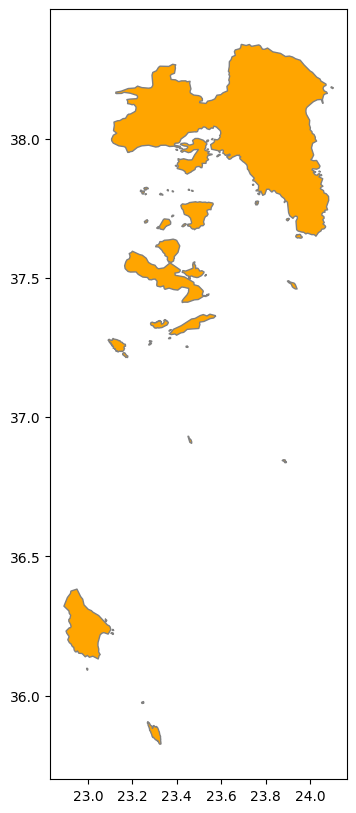

In [14]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [15]:
nuts2_gdf

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
5,EL30,EL,Attiki,Aττική,Greece,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [16]:
nuts2_gdf.drop(columns=['CNTR_CODE','NAME_LATN','CNTR_NAME'], inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'NUTS_NAME')


In [17]:
nuts2_gdf.head(5)

,NUTS_ID,NUTS_NAME,geometry
0,EL30,αττικη,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


<Axes: >

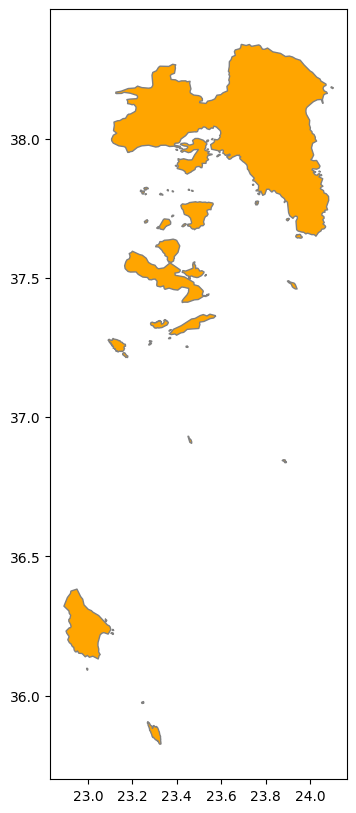

In [18]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [19]:
nuts2_gdf.reset_index(inplace=True, drop = True)

In [20]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='NUTS_ID', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [21]:
df_grid.shape

(737, 5)

In [22]:
df_grid.head()

,geometry,centers,NAME,x,y
0,"POLYGON ((22.93644 36.22024, 22.93644 36.23821...",POINT (22.925364464318083 36.22922756100483),EL30,22.92536,36.22923
1,"POLYGON ((22.93644 36.31008, 22.93644 36.32804...",POINT (22.925364464318083 36.3190610190059),EL30,22.92536,36.31906
2,"POLYGON ((22.93644 36.32804, 22.93644 36.34601...",POINT (22.925364464318083 36.337027710606115),EL30,22.92536,36.33703
3,"POLYGON ((22.95860 36.18431, 22.95860 36.20228...",POINT (22.947523440530137 36.1932941778044),EL30,22.94752,36.19329
4,"POLYGON ((22.95860 36.20228, 22.95860 36.22024...",POINT (22.947523440530137 36.21126086940461),EL30,22.94752,36.21126


In [23]:
df_grid.rename(columns={"NAME": "NUTS2_ID"}, inplace = True)

<Axes: >

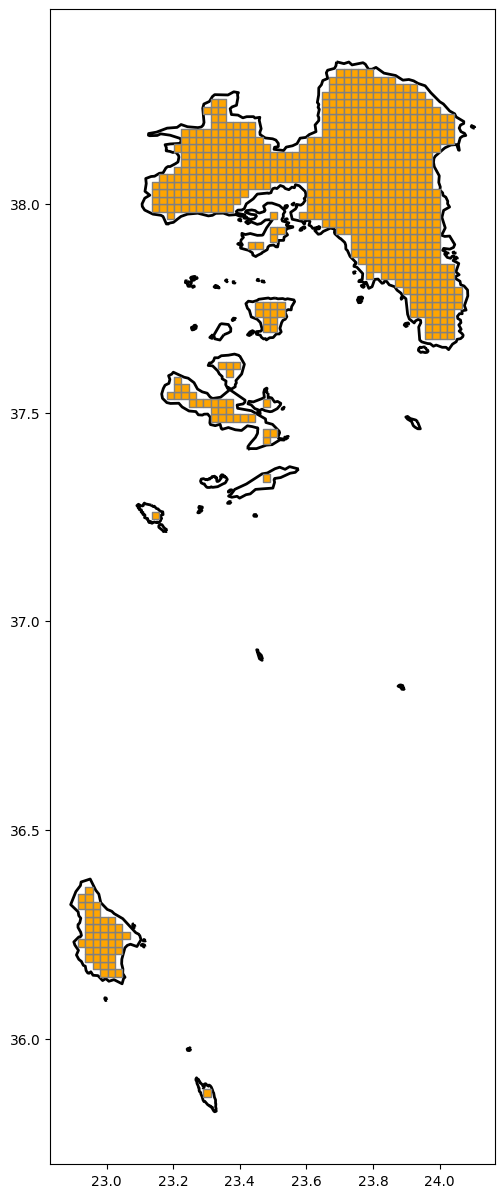

In [24]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [25]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [26]:
nuts2_grid['cell_number'] = nuts2_grid.index

In [27]:
nuts2_grid

,geometry,NUTS2_ID,x,y,cell_number
0,"POLYGON ((22.93644 36.22024, 22.93644 36.23821...",EL30,22.92536,36.22923,0
1,"POLYGON ((22.93644 36.31008, 22.93644 36.32804...",EL30,22.92536,36.31906,1
2,"POLYGON ((22.93644 36.32804, 22.93644 36.34601...",EL30,22.92536,36.33703,2
3,"POLYGON ((22.95860 36.18431, 22.95860 36.20228...",EL30,22.94752,36.19329,3
4,"POLYGON ((22.95860 36.20228, 22.95860 36.22024...",EL30,22.94752,36.21126,4
...,...,...,...,...,...
732,"POLYGON ((24.04439 38.17861, 24.04439 38.19658...",EL30,24.03331,38.18760,732
733,"POLYGON ((24.04439 38.19658, 24.04439 38.21455...",EL30,24.03331,38.20556,733
734,"POLYGON ((24.06655 37.74741, 24.06655 37.76538...",EL30,24.05547,37.75640,734
735,"POLYGON ((24.06655 37.76538, 24.06655 37.78335...",EL30,24.05547,37.77436,735


In [28]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [29]:
nuts2_grid_points

,geometry,NUTS2_ID,x,y,cell_number
0,POINT (22.92536 36.22923),EL30,22.92536,36.22923,0
1,POINT (22.92536 36.31906),EL30,22.92536,36.31906,1
2,POINT (22.92536 36.33703),EL30,22.92536,36.33703,2
3,POINT (22.94752 36.19329),EL30,22.94752,36.19329,3
4,POINT (22.94752 36.21126),EL30,22.94752,36.21126,4
...,...,...,...,...,...
732,POINT (24.03331 38.18760),EL30,24.03331,38.18760,732
733,POINT (24.03331 38.20556),EL30,24.03331,38.20556,733
734,POINT (24.05547 37.75640),EL30,24.05547,37.75640,734
735,POINT (24.05547 37.77436),EL30,24.05547,37.77436,735


<Axes: >

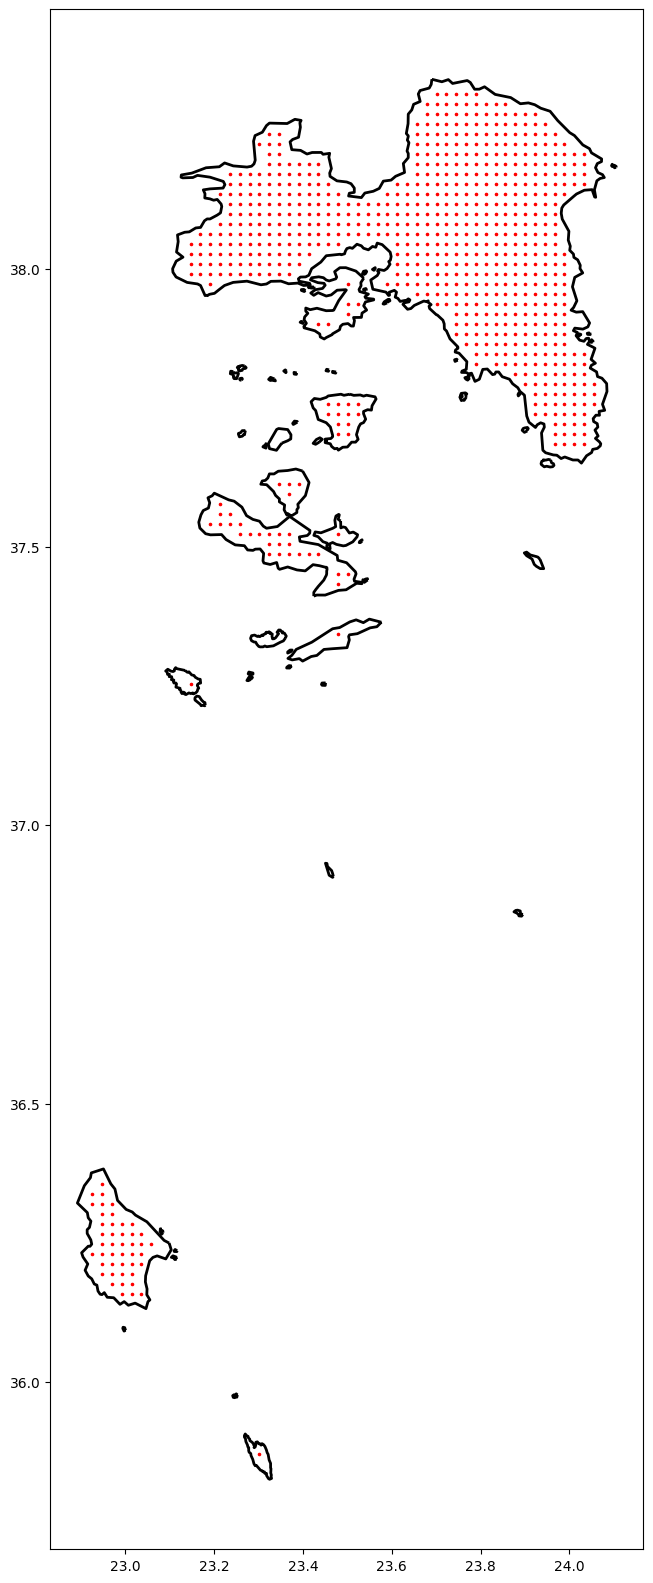

In [30]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [31]:
final_grid = nuts2_grid[['cell_number', 'NUTS2_ID', 'x', 'y', 'geometry']]

final_grid.reset_index(drop = True, inplace= True)

In [32]:
final_grid

,cell_number,NUTS2_ID,x,y,geometry
0,0,EL30,22.92536,36.22923,"POLYGON ((22.93644 36.22024, 22.93644 36.23821..."
1,1,EL30,22.92536,36.31906,"POLYGON ((22.93644 36.31008, 22.93644 36.32804..."
2,2,EL30,22.92536,36.33703,"POLYGON ((22.93644 36.32804, 22.93644 36.34601..."
3,3,EL30,22.94752,36.19329,"POLYGON ((22.95860 36.18431, 22.95860 36.20228..."
4,4,EL30,22.94752,36.21126,"POLYGON ((22.95860 36.20228, 22.95860 36.22024..."
...,...,...,...,...,...
732,732,EL30,24.03331,38.18760,"POLYGON ((24.04439 38.17861, 24.04439 38.19658..."
733,733,EL30,24.03331,38.20556,"POLYGON ((24.04439 38.19658, 24.04439 38.21455..."
734,734,EL30,24.05547,37.75640,"POLYGON ((24.06655 37.74741, 24.06655 37.76538..."
735,735,EL30,24.05547,37.77436,"POLYGON ((24.06655 37.76538, 24.06655 37.78335..."


In [33]:
final_grid.drop(columns='geometry')

,cell_number,NUTS2_ID,x,y
0,0,EL30,22.92536,36.22923
1,1,EL30,22.92536,36.31906
2,2,EL30,22.92536,36.33703
3,3,EL30,22.94752,36.19329
4,4,EL30,22.94752,36.21126
...,...,...,...,...
732,732,EL30,24.03331,38.18760
733,733,EL30,24.03331,38.20556
734,734,EL30,24.05547,37.75640
735,735,EL30,24.05547,37.77436


In [34]:
final_grid.drop(columns='geometry').to_csv(f'../../data/{NUTS2}/GR_{NUTS2}_GRID.csv', encoding=enc, index = False)

In [35]:
final_grid.to_file(f'../../data/{NUTS2}/GR_{NUTS2}_GRID.shp', encoding = 'utf-8')